In [1]:
import os
import json
from ultralytics import RTDETR
import cv2
import matplotlib.pyplot as plt

In [2]:
# Load a COCO-pretrained RT-DETR-l model
model = RTDETR('rtdetr-l.pt')
# Display model information (optional)
model.info()

rt-detr-l summary: 673 layers, 32970476 parameters, 0 gradients


(673, 32970476, 0, 0)

In [3]:
coco_id2name = json.load(open('coco_id2name.json'))

In [4]:
scannet_path = '../data/ScanNet/scannet_by_tr3d_with_DepthImage/posed_images'
scene_id = 'scene0000_00'
frame = '00000'
path = f'{scannet_path}/{scene_id}/{frame}.jpg'
# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model(path)


image 1/1 /home/alan/obj_graph_matching/object-detection/../data/ScanNet/scannet_by_tr3d_with_DepthImage/posed_images/scene0000_00/00000.jpg: 640x640 1 56, 1 59, 1 60, 2 65s, 5 73s, 140.6ms
Speed: 8.3ms preprocess, 140.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


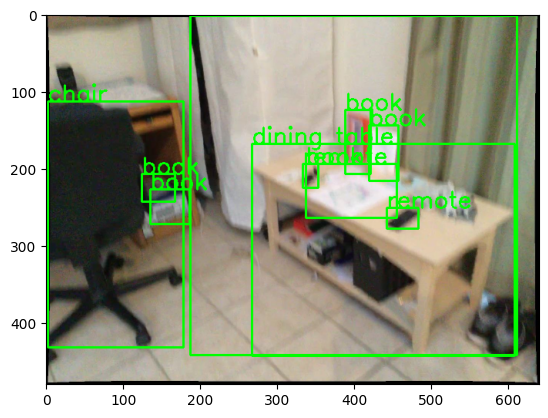

In [6]:
result = results[0]

orig_img = (1296, 968)
img_size = (640, 480)
img = cv2.cvtColor(result.orig_img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, img_size)

for box in result.boxes:
    cls_id = int(box.cls.item())
    cls_name = coco_id2name[str(cls_id)]
    xyxy = box.xyxy.cpu().numpy()[0].astype(int)
    xyxy[0] = int(xyxy[0] * img_size[0] / orig_img[0])
    xyxy[1] = int(xyxy[1] * img_size[1] / orig_img[1])
    xyxy[2] = int(xyxy[2] * img_size[0] / orig_img[0])
    xyxy[3] = int(xyxy[3] * img_size[1] / orig_img[1]) 
    cv2.rectangle(img, (xyxy[0], xyxy[1]), (xyxy[2], xyxy[3]), (0, 255, 0), 2)
    cv2.putText(img, f'{cls_name}', (xyxy[0], xyxy[1]), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

plt.imshow(img)